## 1. Завантаження feature_matrix.parquet


In [2]:
import sys
from pathlib import Path

project_root = Path('..').resolve()
sys.path.append(str(project_root))

import numpy as np
import pandas as pd
import plotly.express as px
from sklearn.preprocessing import RobustScaler

from src.pipelines import wfv_orchestrator

processed_dir = project_root / 'data' / 'processed'
feature_df = pd.read_parquet(processed_dir / 'feature_matrix.parquet')
target_h1 = pd.read_parquet(processed_dir / 'target_h1.parquet')
target_series = target_h1.iloc[:, 0]

## 2. Визначення max_lag_order — AIC plot по p від 1 до 20


In [3]:
from statsmodels.tsa.ar_model import AutoReg

series = target_series.dropna().values
aic_values = {}
for p in range(1, 21):
    model = AutoReg(series, lags=p, old_names=False).fit()
    aic_values[p] = model.aic

aic_df = pd.DataFrame({'lag': list(aic_values.keys()), 'aic': list(aic_values.values())})
fig = px.line(aic_df, x='lag', y='aic', markers=True, title='AIC by Lag Order')
fig.show()

## 3. Демонстрація feature selection на першому WFV fold


In [4]:
config = wfv_orchestrator.WFVConfig()
train_end = config.w_train
X_train = feature_df.iloc[:train_end]
y_train = target_series.loc[X_train.index]

scaler = RobustScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    index=X_train.index,
    columns=X_train.columns,
)

granger_features, f_stats = wfv_orchestrator._select_features_granger(
    X_train_scaled,
    y_train,
    config,
)
vif_features = wfv_orchestrator._select_features_vif(X_train_scaled[granger_features], config)
corr_features = wfv_orchestrator._select_features_correlation(
    X_train_scaled[vif_features],
    f_stats,
    config,
)
shap_features = wfv_orchestrator._select_features_shap(
    X_train_scaled[corr_features],
    y_train,
    config,
)

summary = pd.DataFrame({
    'stage': ['raw', 'granger', 'vif', 'pearson', 'shap'],
    'n_features': [
        X_train.shape[1],
        len(granger_features),
        len(vif_features),
        len(corr_features),
        len(shap_features),
    ]
})
summary

/home/majestic/projects/OilOracle/.venv/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/home/majestic/projects/OilOracle/.venv/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/home/majestic/projects/OilOracle/.venv/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/home/majestic/projects/OilOracle/.venv/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/home/majestic/projects/OilOracle/.venv/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/home

,stage,n_features
0,raw,28
1,granger,24
2,vif,19
3,pearson,18
4,shap,15


## 4. SHAP beeswarm plot для LightGBM на першому fold


<Axes: xlabel='SHAP value (impact on model output)'>

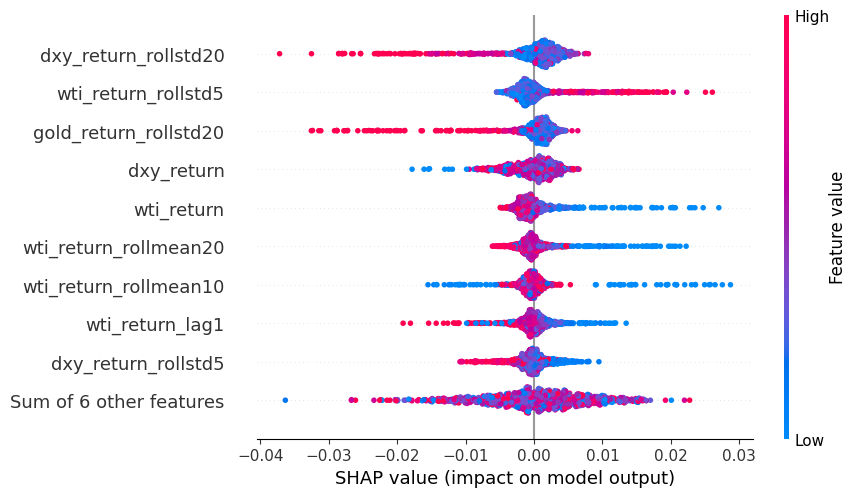

In [5]:
import lightgbm as lgb
import shap

model = lgb.LGBMRegressor(n_estimators=200, learning_rate=0.05, num_leaves=31)
model.fit(X_train_scaled[shap_features], y_train)

explainer = shap.TreeExplainer(model)
shap_values = explainer(X_train_scaled[shap_features])
shap.plots.beeswarm(shap_values, show=False)

## 5. Feature importance evolution (heatmap: fold × feature)


In [6]:
import json
from pathlib import Path

project_root = Path('..').resolve()
processed_dir = project_root / 'data' / 'processed'

audit_files = sorted(processed_dir.glob('audit_random_forest_1.json'))
if not audit_files:
    print('No audit logs found. Run WFV first.')
else:
    audit = json.loads(audit_files[0].read_text())
    feature_sets = []
    fold_ids = []
    for entry in audit:
        fold_ids.append(entry['fold_idx'])
        feature_sets.append(entry['selected_features'])
    all_features = sorted({feat for feats in feature_sets for feat in feats})
    matrix = np.zeros((len(fold_ids), len(all_features)))
    for i, feats in enumerate(feature_sets):
        for feat in feats:
            matrix[i, all_features.index(feat)] = 1
    fig = px.imshow(matrix, labels={'x': 'feature', 'y': 'fold', 'color': 'selected'},
                   x=all_features, y=fold_ids, title='Feature Selection Evolution')
    fig.show()